# Esercitazione software 2

## Filtraggio di segnali musicali campionati 

Autori:

- Fissolo Emanuele - *s323585*
- Flora Alessandro - *s321504*
- Giraudo Giacomo - *s321784*
- Intagliata Francesco - *s325961*

### 1) Operazioni preliminari
In questa cella vengono eseguite le operazioni preliminari necessarie al funzionamento del codice, quali la lettura della traccia audio, la definizione della dimensione della finestra da analizzare etc...

In [1]:
#in questo blocco eseguiamo tutte le operazione preliminari necessarie per il funzionamento dei
#blocchi di codice successivi

import numpy as np
from cmath import exp, pi
import matplotlib.pyplot as plt
import tes, soundfile, os
from tes import Tipo_filtro
from IPython.display import Audio, display

file_audio = str(os.path.join('input', 'CornfieldChase.oga'))
#file_audio = str(os.path.join('input', 'QueenBohemianRhapsody.oga'))

audio, fs = soundfile.read(file_audio)
audio = np.array(audio[:, 0], dtype=np.float32)

len_finestra = 0.5
N = int(fs*len_finestra)   #finestra da 0.5 secondi
len_sec = len(audio)/fs

Df = 1/(N*1/fs)
x_axis_f = [x*Df for x in range(int(-N/2),int(N/2))]
x_axis_t = [x for x in range(0, len(audio))]

print(f"Estratti {len(audio)} campioni - campionati a {fs/1000:.1f}kHz - durata {len_sec} secondi")
print(f"Lavoriamo con finestre da {len_finestra:.1f} secondi - {N} campioni per finestra - risoluzione in frequenza {Df:.2f}Hz")


Estratti 882000 campioni - campionati a 44.1kHz - durata 20.0 secondi
Lavoriamo con finestre da 0.5 secondi - 22050 campioni per finestra - risoluzione in frequenza 2.00Hz


#### Anteprima del file audio
La seguente cella consente di ottenere un'anteprima del file audio riproducendolo - la sua mancata riproduzione non inficia sul resto dell'elaborazione

In [2]:
display(Audio(file_audio))

#### Prova applicazione filtro "Porta"

Generiamo un filtro "porta discreta nel tempo", che si comporta come un filtro passa-basso in frequenza. Vogliamo creare questo filtro in modo che abbia una frequenza di taglio a 3dB attorno alla frequenza 1KHz.

In [ ]:
len_filtro = tes.get_durata_per_taglio(1000, Tipo_filtro.PORTA, 0)
h_t = tes.get_porta_discreta(len_filtro, 0, fs, int(len_filtro*fs))
h_t = h_t / sum(h_t)

audio_filtrato = np.convolve(audio, h_t, mode = "same")
plt.plot(x_axis_t, audio_filtrato)
plt.show()

Proviamo ad ascoltare il nuovo segnale audio

In [7]:
file_out1 = str(os.path.join('output', 'CornfieldChaseFilter1.wav'))
soundfile.write(file=file_out1, data=audio_filtrato, samplerate=fs)

display(Audio(file_out1))

#### Prova applicazione filtro "Coseno rialzato"

Generiamo un filtro "coseno rialzato nel tempo" con beta = 0.5, che si comporta sempre come un filtro passa-basso

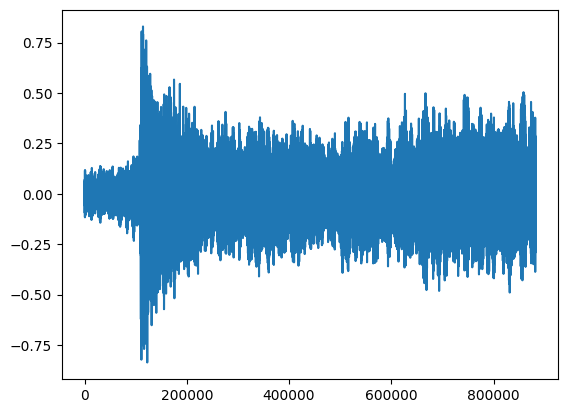

In [5]:
len_filtro = len_filtro = tes.get_durata_per_taglio(1000, Tipo_filtro.COS_RIALZATO, 0.5)
h_t = tes.get_coseno_rialzato(len_filtro, len_filtro/2, fs, int(len_filtro*fs), 0.5)
h_t = h_t / sum(h_t)

audio_filtrato = np.convolve(audio, h_t, mode = "same")
plt.plot(x_axis_t, audio_filtrato)
plt.show()

Proviamo ad ascoltare il nuovo segnale audio

In [6]:
file_out2 = str(os.path.join('output', 'CornfieldChaseFilter2.wav'))
soundfile.write(file=file_out2, data=audio_filtrato, samplerate=fs)

display(Audio(file_out2))